# Pendulum Random Baseline

## 实验目标

这个 notebook 不训练任何策略，只统计 `Pendulum-v1` 在随机连续动作下的表现。目标是先建立一个清晰基线：在需要持续控制力矩、把摆杆拉回竖直并抑制角速度的任务里，随机动作通常只能带来高能耗和大幅振荡。后续 `SAC` 的训练结果会以这份 baseline 作为参照。

## 环境背景

`Pendulum-v1` 是经典的连续动作控制环境。智能体需要输出连续力矩，把下垂摆杆拉到接近竖直的位置，同时尽量压低角速度和控制代价。这个任务适合说明：

- 连续动作控制不能直接套用离散动作枚举
- 控制目标不仅是到达某个位置，还包括稳定性和能耗
- 反馈策略需要在整个轨迹中持续细调输出

## 方法说明

这里的方法就是纯随机动作采样：每一步从动作空间中随机取一个连续力矩，不维护价值函数，也不更新策略。它不是正式算法，但它能直观说明随机力矩为什么很难形成稳定的姿态控制。

## 设备与并行说明

- 本实验使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不启用并行环境

这里主要做环境交互统计，不涉及神经网络训练。

In [1]:
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [2]:
ENV_ID = "Pendulum-v1"
NUM_EPISODES = 500
MAX_STEPS = 200
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
QUALITY_THRESHOLD_RETURN = -300
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)

## 参数选择说明

- `NUM_EPISODES = 500`：让随机统计结果足够稳定，同时控制执行时间
- `MAX_STEPS = 200`：与环境标准回合长度一致
- `QUALITY_THRESHOLD_RETURN = -300`：作为接近可控状态的粗略判断线

这里的重点不是训练，而是建立一个连续控制基线：随机力矩通常会让摆杆一直大幅摆动，既难以保持竖直，也很难减少角速度。

In [3]:
episode_rewards = []
final_angle_errors = []
mean_abs_angular_velocities = []
quality_flags = []

for episode in tqdm(range(NUM_EPISODES), desc="Random episodes"):
    obs, info = env.reset(seed=SEED + episode)
    total_reward = 0.0
    angular_velocities = []

    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        angular_velocities.append(abs(float(obs[2])))
        if terminated or truncated:
            break

    theta = float(np.arctan2(obs[1], obs[0]))
    angle_error = float(abs(((theta + np.pi) % (2 * np.pi)) - np.pi))
    episode_rewards.append(total_reward)
    final_angle_errors.append(angle_error)
    mean_abs_angular_velocities.append(float(np.mean(angular_velocities)))
    quality_flags.append(int(total_reward >= QUALITY_THRESHOLD_RETURN))

env.close()

Random episodes:   0%|          | 0/500 [00:00<?, ?it/s]

In [4]:
summary = pd.DataFrame({
    "reward": episode_rewards,
    "final_angle_error": final_angle_errors,
    "mean_abs_angular_velocity": mean_abs_angular_velocities,
    "quality_flag": quality_flags,
})
summary.describe(include="all")

,reward,final_angle_error,mean_abs_angular_velocity,quality_flag
count,500.000000,500.000000,500.000000,500.0
mean,-1239.778895,2.064266,2.859518,0.0
std,293.191903,0.825564,1.108271,0.0
min,-1860.120530,0.018537,0.363433,0.0
25%,-1490.819151,1.478920,1.918074,0.0
50%,-1194.601356,2.266169,3.252714,0.0
75%,-979.452887,2.761274,3.721682,0.0
max,-735.658471,3.135529,4.831226,0.0


In [5]:
metrics = pd.DataFrame({
    "metric": [
        "average_reward",
        "quality_rate",
        "average_final_angle_error",
        "average_mean_abs_angular_velocity",
    ],
    "value": [
        float(np.mean(episode_rewards)),
        float(np.mean(quality_flags)),
        float(np.mean(final_angle_errors)),
        float(np.mean(mean_abs_angular_velocities)),
    ],
})
metrics

,metric,value
0,average_reward,-1239.778895
1,quality_rate,0.000000
2,average_final_angle_error,2.064266
3,average_mean_abs_angular_velocity,2.859518


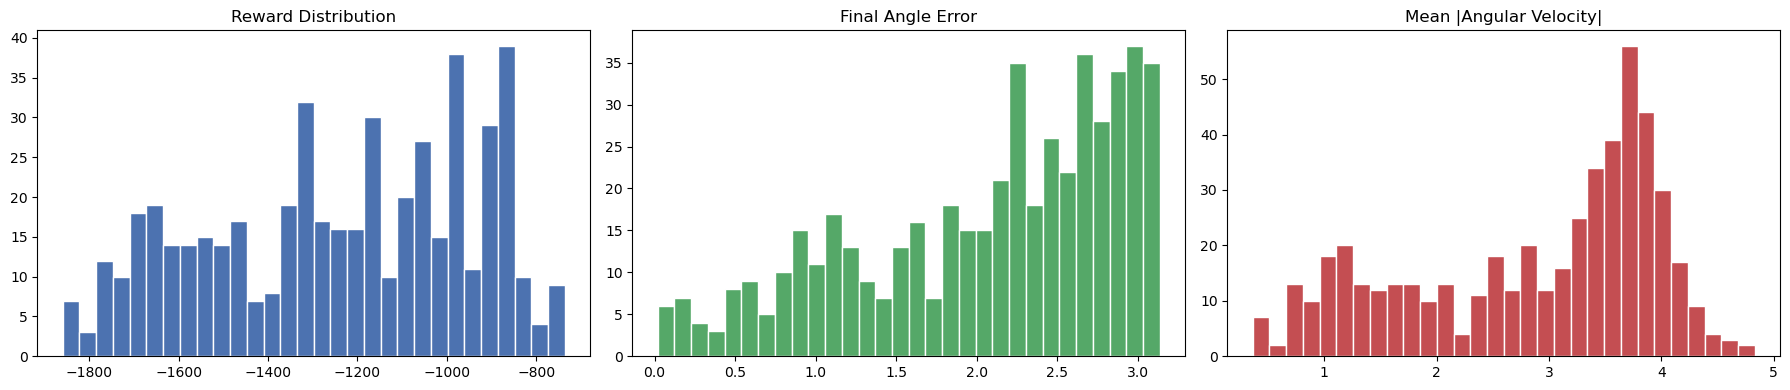

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(episode_rewards, bins=30, color="#4c72b0", edgecolor="white")
axes[0].set_title("Reward Distribution")

axes[1].hist(final_angle_errors, bins=30, color="#55a868", edgecolor="white")
axes[1].set_title("Final Angle Error")

axes[2].hist(mean_abs_angular_velocities, bins=30, color="#c44e52", edgecolor="white")
axes[2].set_title("Mean |Angular Velocity|")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_baseline_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = rollout_env.reset(seed=SEED + 1000 + rollout_idx)
    frames = []
    total_reward = 0.0

    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)
        action = rollout_env.action_space.sample()
        obs, reward, terminated, truncated, info = rollout_env.step(action)
        total_reward += reward
        if terminated or truncated:
            break

    theta = float(np.arctan2(obs[1], obs[0]))
    angle_error = float(abs(((theta + np.pi) % (2 * np.pi)) - np.pi))
    final_frame = rollout_env.render()
    if final_frame is not None:
        frames.extend([final_frame] * 20)
    rollout_summaries.append({
        "rollout_index": rollout_idx + 1,
        "seed": SEED + 1000 + rollout_idx,
        "total_reward": float(total_reward),
        "final_angle_error": angle_error,
        "final_angular_velocity": float(obs[2]),
    })
    if frames:
        imageio.mimsave(RESULTS_DIR / f"random_baseline_rollout_{rollout_idx + 1}.gif", frames, fps=ROLLOUT_FPS)
    rollout_env.close()

pd.DataFrame(rollout_summaries)

,rollout_index,seed,total_reward,final_angle_error,final_angular_velocity
0,1,1042,-1177.166853,1.067209,1.591933
1,2,1043,-1425.432010,2.272309,2.785139
2,3,1044,-1650.834932,2.805301,-2.903234


In [8]:
summary.to_csv(RESULTS_DIR / "random_baseline_episode_summary.csv", index=False)
metrics.to_csv(RESULTS_DIR / "random_baseline_metrics.csv", index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / "random_baseline_rollout_summary.csv", index=False)
print(metrics.to_string(index=False))

                           metric        value
                   average_reward -1239.778895
                     quality_rate     0.000000
        average_final_angle_error     2.064266
average_mean_abs_angular_velocity     2.859518


## 结果解读

如果随机基线的平均回报很低、末端角误差较大且角速度长期偏高，就说明 Pendulum 的关键不只是摆到某个角度，而是持续输出细粒度力矩来兼顾姿态、速度和能耗。